In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier


data = {
    'product': ['Shirts', 'Trousers', 'Dresses', 'Shoes', 'Bags'],
    'price':   [1000, 2000, 3000, 1500, 800],
    'sold':    [50, 30, 20, 40, 60]
}

df = pd.DataFrame(data)
print(df)

    product  price  sold
0    Shirts   1000    50
1  Trousers   2000    30
2   Dresses   3000    20
3     Shoes   1500    40
4      Bags    800    60


In [12]:
average_price = df['price'].mean()
print(f"Average price of products: {average_price}")
# sabse zyada biknay wala product kaun sa hai
most_sold_product = df.loc[df['sold'].idxmax()]['product']
print(f"Most sold product: {most_sold_product}")
# total revenue ka column 
df['revenue'] = df['price'] * df['sold']
print(df)

Average price of products: 1660.0
Most sold product: Bags
    product  price  sold  revenue
0    Shirts   1000    50    50000
1  Trousers   2000    30    60000
2   Dresses   3000    20    60000
3     Shoes   1500    40    60000
4      Bags    800    60    48000


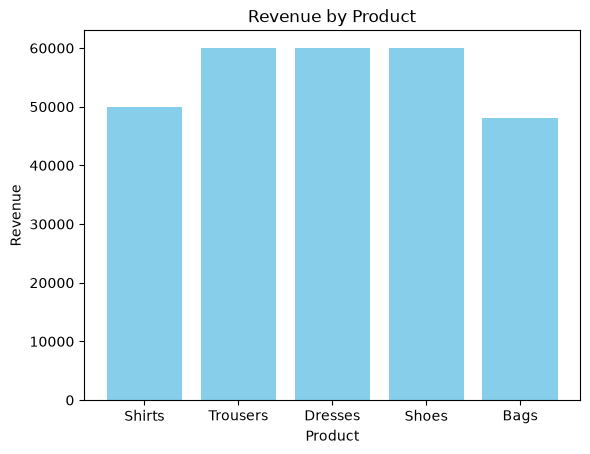

In [13]:
# Bar chart priduct vs revenue
plt.bar(df['product'], df['revenue'], color='skyblue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.title('Revenue by Product')
plt.show()


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Target variable define karein
df['popular'] = (df['sold'] > 40).astype(int)

# 2. Features select karein (Agar baaki columns hain toh unhe bhi add karein)
# Example: X = df[['price', 'rating', 'views']]
X = df[['price', 'sold', 'revenue']]
Y = df['popular']
print(df)
# 3. Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# 4. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)
print("Model trained successfully.")

# 5. Evaluation
y_pred = model.predict(X_test)
print(f"Predictions: {y_pred}")
print(f"Actual:      {Y_test.values}")

accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

    product  price  sold  revenue  popular
0    Shirts   1000    50    50000        1
1  Trousers   2000    30    60000        0
2   Dresses   3000    20    60000        0
3     Shoes   1500    40    60000        0
4      Bags    800    60    48000        1
Model trained successfully.
Predictions: [0]
Actual:      [0]
Accuracy: 100.00%
